# **Dataset API Prototype**

In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt


I0000 00:00:1780489992.857388   91774 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## WM_811K Dataset Class

In [3]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(96,96))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## Single Defect Tensorflow Dataset

I0000 00:00:1780491277.610673   91774 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


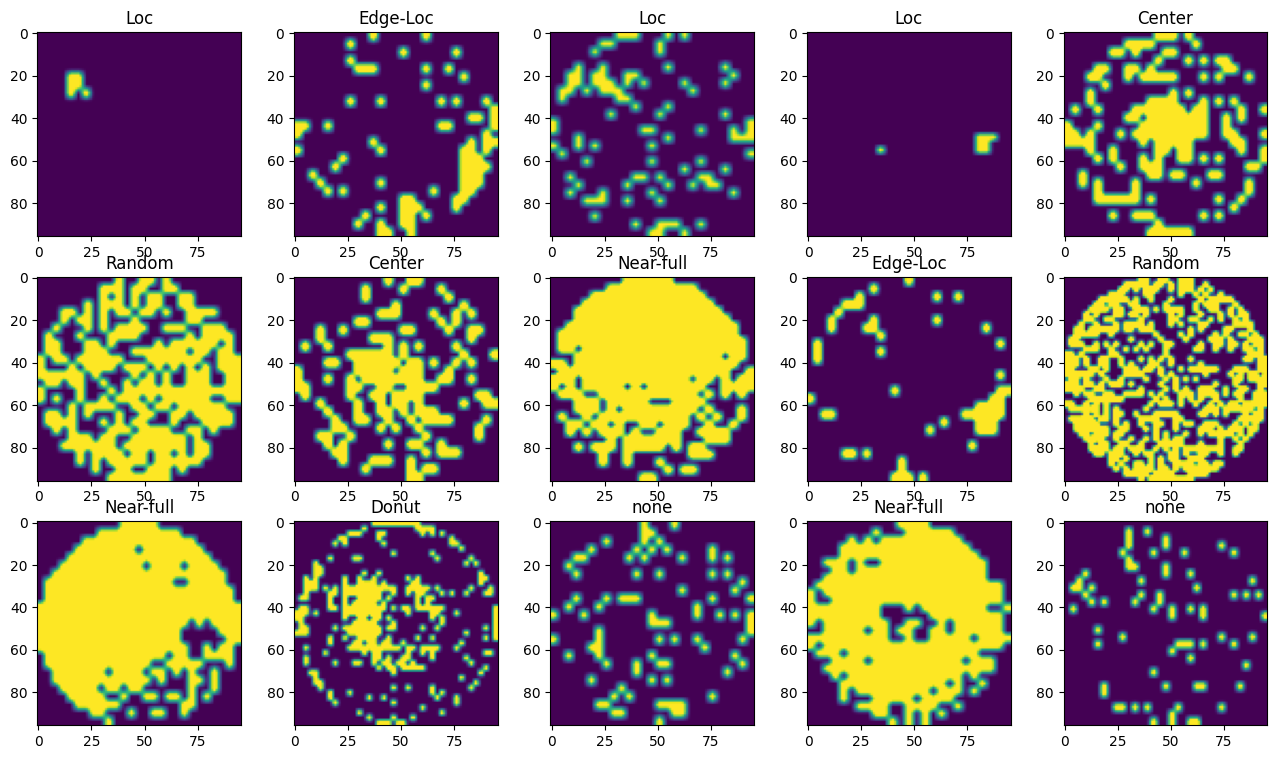

In [4]:
N_VIEW = 15
cols = min(N_VIEW, 5)
rows = (N_VIEW + cols - 1) // cols

_,axs = plt.subplots(rows,cols, figsize=(16,9))

ds = wm811k.dataset_single_defect()
for ax, (img, label) in zip(axs.flatten(), ds.take(N_VIEW)):
    ax.imshow(img)
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    ax.set_title(WM_811K.defect_from_int[i])
    

Center


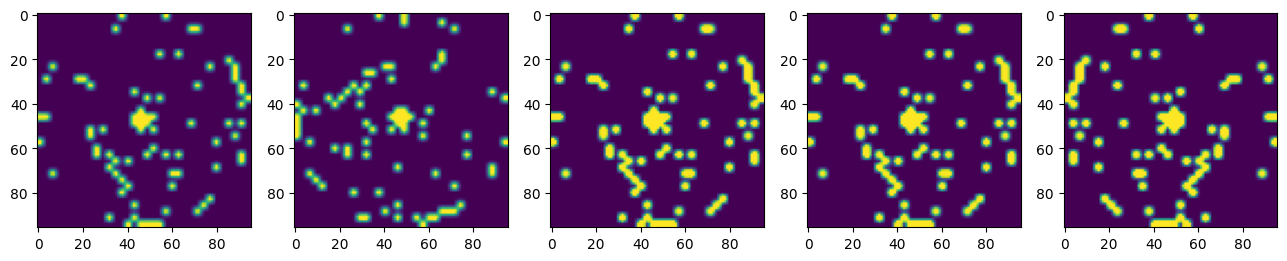

In [7]:
for img, label in ds.take(1):
    _, axs = plt.subplots(1,5, figsize=(16,4))
    axs[0].imshow(img)
    axs[1].imshow(wm811k.augment_image(img))
    axs[2].imshow(wm811k.augment_image(img))
    axs[3].imshow(wm811k.augment_image(img))
    axs[4].imshow(wm811k.augment_image(img))
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    print(WM_811K.defect_from_int[i])

## Multi Defect Tensorflow Dataset

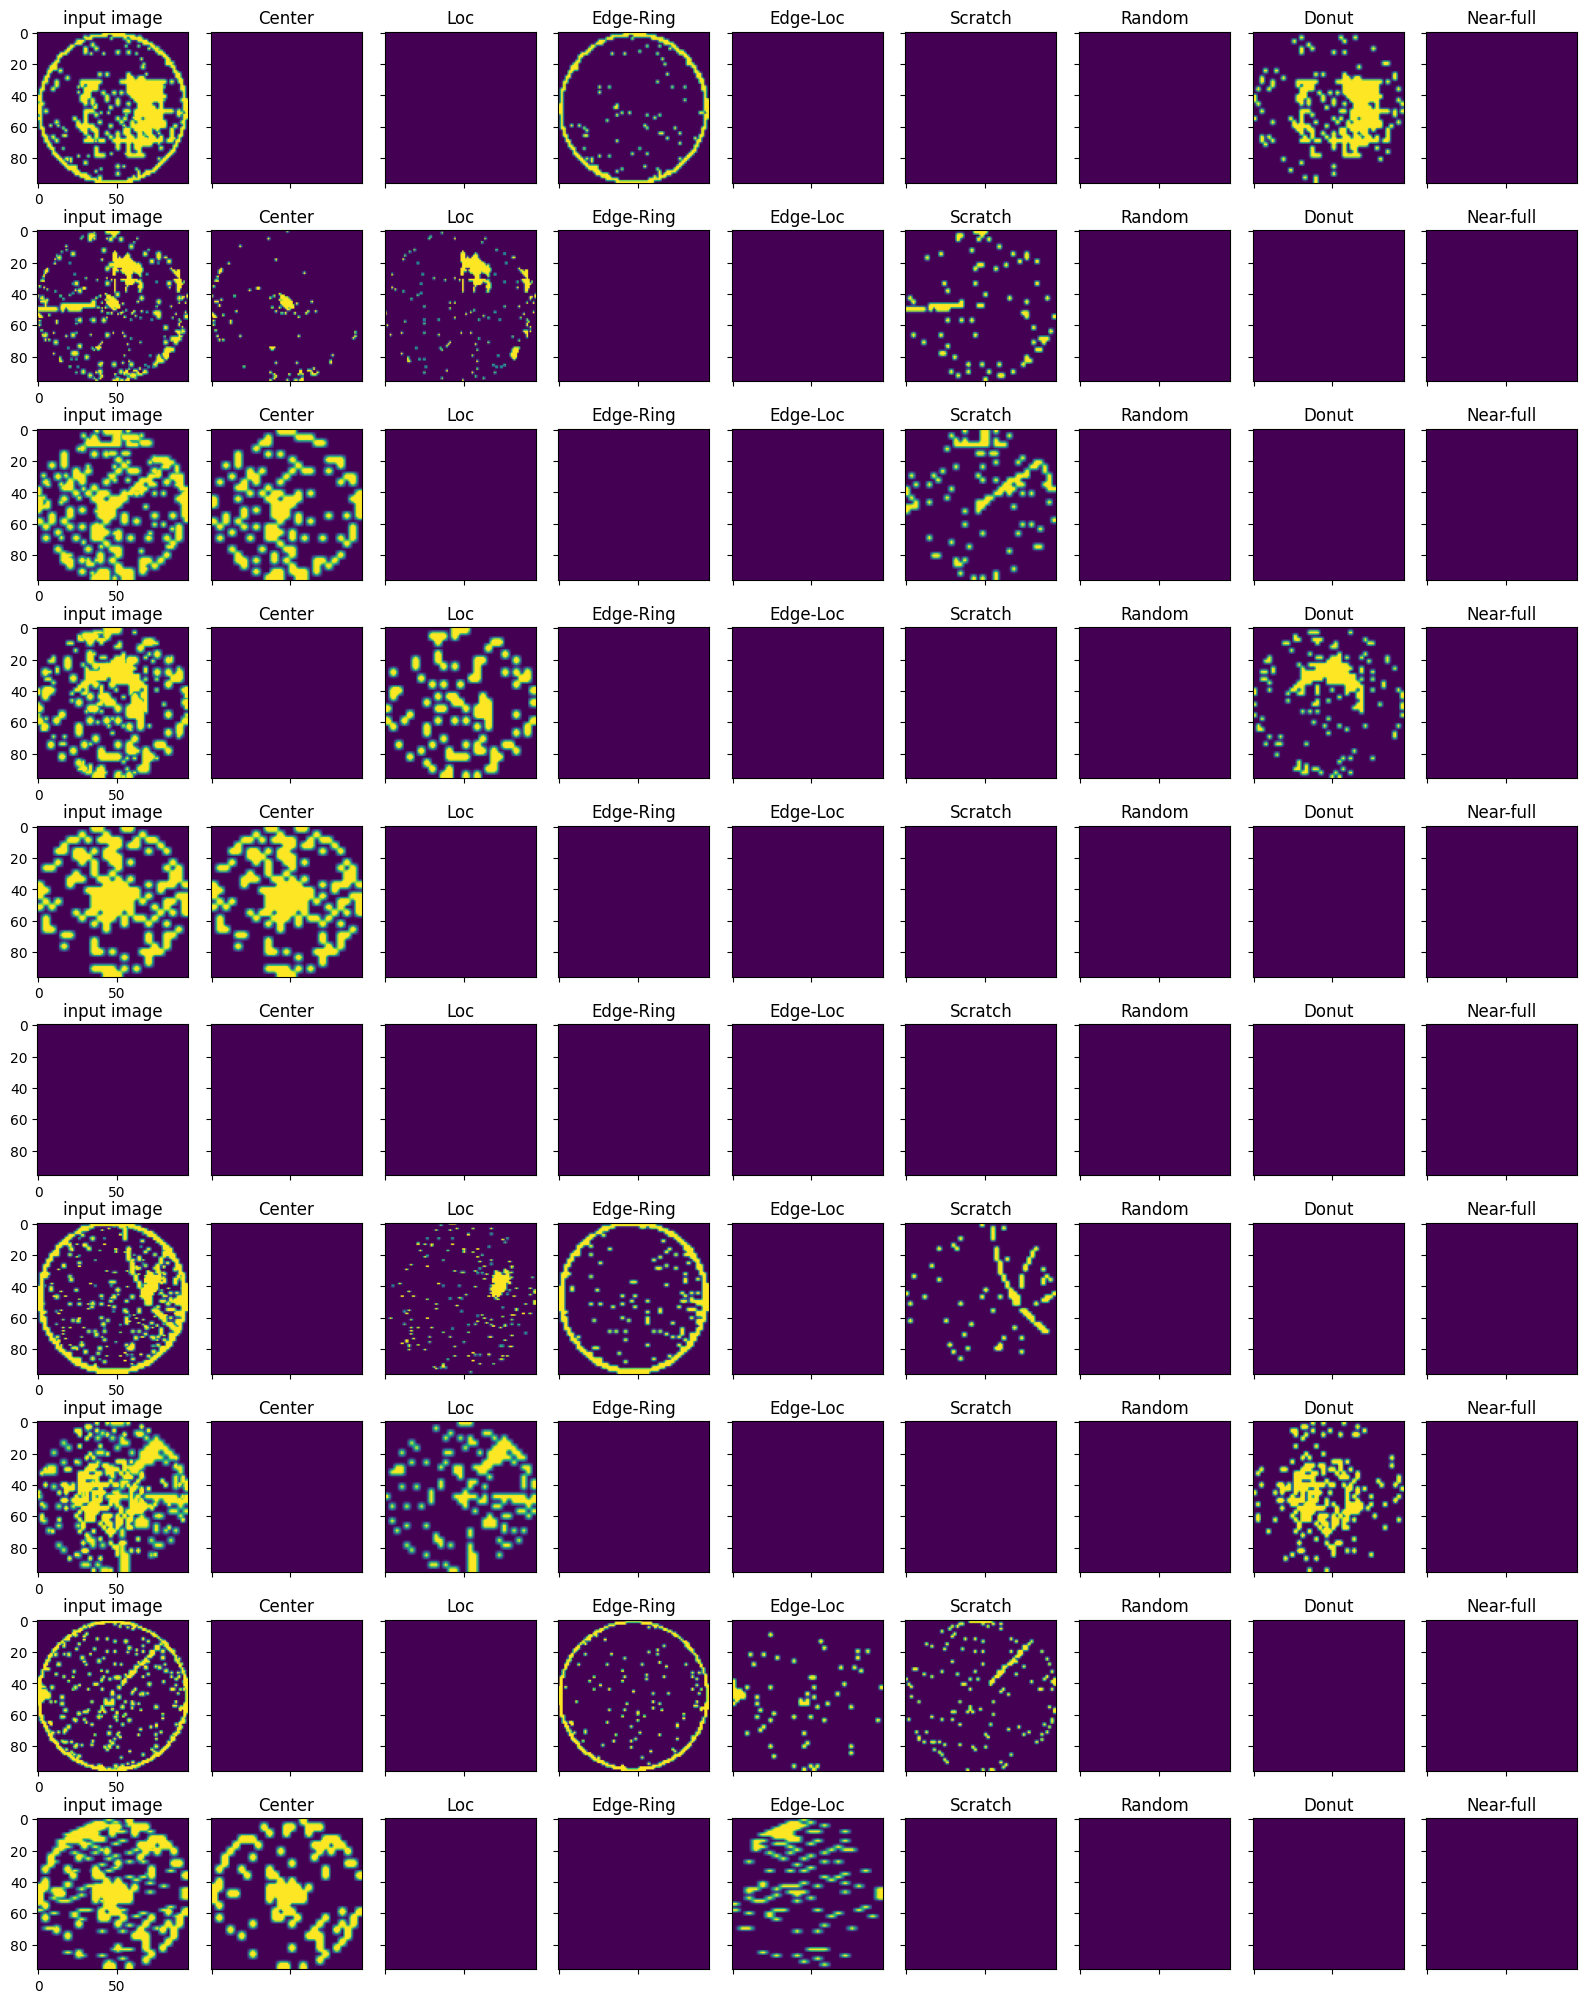

In [8]:
N_VIEW = 10
_,axs = plt.subplots(N_VIEW, 9, figsize=(16, 2*N_VIEW))

ds = wm811k.dataset_multi_defect_segmentation()
for row, (input_img, mid_stack) in enumerate(ds.take(N_VIEW)):
    axs[row,0].imshow(input_img)
    axs[row,0].set_title('input image')
    for col in range(8):
        axs[row,col+1].imshow(mid_stack[:,:,col])
        axs[row,col+1].set_title(WM_811K.defect_from_int[col])
        axs[row,col+1].set_xticklabels([])
        axs[row,col+1].set_yticklabels([])

plt.tight_layout()

## 1. Train Segmentation Model

In [ ]:
# create segmentation model with U-Net like structure
def create_segmentation_model():
    def conv_block(x, f, pad='valid', halve=True):
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        return x

    def deconv_block(xA, xB, f, pad='valid', double=True):
        x = tf.keras.layers.Concatenate(axis=-1)([xA,xB])
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if double:
            x = tf.keras.layers.Conv2DTranspose(f//2, (2,2), activation='relu', strides=(2,2))(x)
        return x

    img_input = tf.keras.layers.Input(shape=(*wm811k.imsize, 1))

    # encoder blocks
    x1 = conv_block(img_input, 32, 'same', False)
    x2 = conv_block(x1, 64)
    x3 = conv_block(x2, 128)
    x4 = conv_block(x3, 256)

    # dense block
    x5 = tf.keras.layers.GlobalAveragePooling2D()(x4)
    x5 = tf.keras.layers.Dense(256)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Reshape((1,1,256))(x5)
    x5 = tf.keras.layers.Conv2DTranspose(64, (5,5), activation='relu')(x5)

    # decoder blocks
    x6 = deconv_block(x4, x5, 128)
    x7 = deconv_block(x3, x6, 128)
    x8 = deconv_block(x2, x7, 64)
    x9 = deconv_block(x1, x8, 32, 'same', False)

    imgs_output = tf.keras.layers.Conv2D(WM_811K.n_classes-1, (3,3), activation='sigmoid', padding='same')(x9)
    return tf.keras.Model(inputs=img_input, outputs=imgs_output)


model_segmentation = create_segmentation_model()
model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)
model_segmentation.summary()

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_294 (Conv2D) │ (None, 96, 96,    │        320 │ input_layer_37[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_295 (Conv2D) │ (None, 96, 96,    │      9,248 │ conv2d_294[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_206         │ (None, 96, 96,    │          0 │ conv2d_295[0][0]  │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ dropout_206[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_114   │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_296 (Conv2D) │ (None, 46, 46,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_297 (Conv2D) │ (None, 44, 44,    │     36,928 │ conv2d_296[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_207         │ (None, 44, 44,    │          0 │ conv2d_297[0][0]  │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        256 │ dropout_207[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_115   │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_298 (Conv2D) │ (None, 20, 20,    │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_299 (Conv2D) │ (None, 18, 18,    │    147,584 │ conv2d_298[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_208         │ (None, 18, 18,    │          0 │ conv2d_299[0][0]  │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ dropout_208[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_116   │ (None, 9, 9, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_300 (Conv2D) │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_11

 Total params: 2,750,344 (10.49 MB)

 Trainable params: 2,748,680 (10.49 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [46]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [83]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_segmentation().batch(16)

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=3,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0581
Epoch 1: loss improved from None to 0.04920, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - loss: 0.0492
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0337
Epoch 2: loss improved from 0.04920 to 0.03272, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - loss: 0.0327
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0301
Epoch 3: loss improved from 0.03272 to 0.02911, saving model to ../models/multi_defect_segmentation.keras

Epoch 3: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - loss: 0.0291
Restoring model weights from the end of the best epoch: 3.


In [84]:
input_img_batch, output_imgs_batch = list(ds_train.take(1))[0]
pred_batch = model_segmentation.predict(input_img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


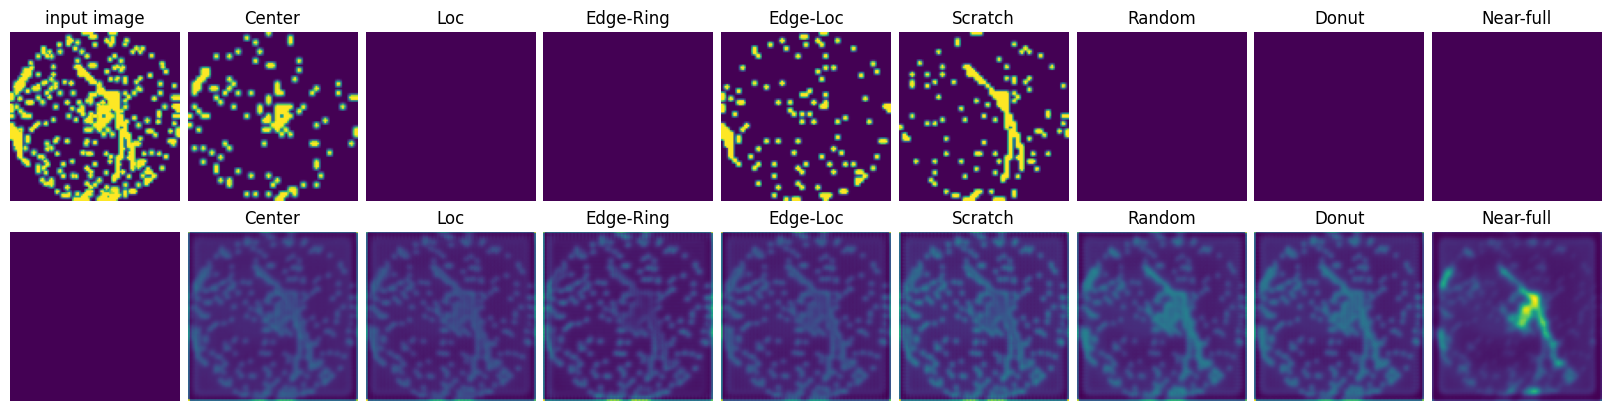

In [85]:
idx = 3
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(input_img_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(output_imgs_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))

## 2. Train Classification Model

In [ ]:
model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid')
    tf.keras.layers.Dense(8, activation='softmax')
    
    ])

model_classification.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
)

# proper loss function and metrics
# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
# )


model_classification.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 62, 62, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,726,248 (10.40 MB)

 Trainable params: 2,723,752 (10.39 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_classification.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_classification().batch(16)
ds_validation = wm811k.dataset_multi_defect_classification().batch(16)

history = model_classification.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - loss: 4.6335
Epoch 1: val_loss improved from None to 4.13013, saving model to ../models/multi_defect_classification.keras

Epoch 1: finished saving model to ../models/multi_defect_classification.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 76s 555ms/step - loss: 4.1014 - val_loss: 4.1301
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - loss: 3.3951
Epoch 2: val_loss did not improve from 4.13013
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 556ms/step - loss: 3.3662 - val_loss: 5.3836
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 3.3263
Epoch 3: val_loss did not improve from 4.13013
128/128 ━━━━━━━━━━━━━━━━━━━━ 72s 565ms/step - loss: 3.3188 - val_loss: 4.3792
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - loss: 3.3308
Epoch 4: val_loss improved from 4.13013 to 3.63316, saving model to ../models/multi_defect_classification.keras

Epoch 4: finished saving model to ../models/multi_defect_classification.keras
128/128 ━━━━━━━━━

## 3. Train Combined Full Stack Model

In [29]:
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification    
])

model_fullstack.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), metrics=["accuracy"]
)

model_fullstack.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 64, 64, 8)      │        76,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 8)              │     2,726,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,802,288 (10.69 MB)

 Trainable params: 2,799,392 (10.68 MB)

 Non-trainable params: 2,896 (11.31 KB)

In [35]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_fullstack().batch(16)
ds_validation = wm811k.dataset_multi_defect_fullstack().batch(16)

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.3379 - loss: 4.4229
Epoch 1: val_loss improved from None to 2.66255, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 771ms/step - accuracy: 0.3423 - loss: 4.5206 - val_accuracy: 0.3555 - val_loss: 2.6625
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.3599 - loss: 4.5912
Epoch 2: val_loss did not improve from 2.66255
128/128 ━━━━━━━━━━━━━━━━━━━━ 86s 674ms/step - accuracy: 0.3560 - loss: 4.5533 - val_accuracy: 0.2988 - val_loss: 2.8659
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3665 - loss: 4.5748
Epoch 3: val_loss did not improve from 2.66255
128/128 ━━━━━━━━━━━━━━━━━━━━ 78s 615ms/step - accuracy: 0.3569 - loss: 4.6785 - val_accuracy: 0.3008 - val_loss: 2.8108
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.3400 - loss: 4.6825
Epoch 4: val

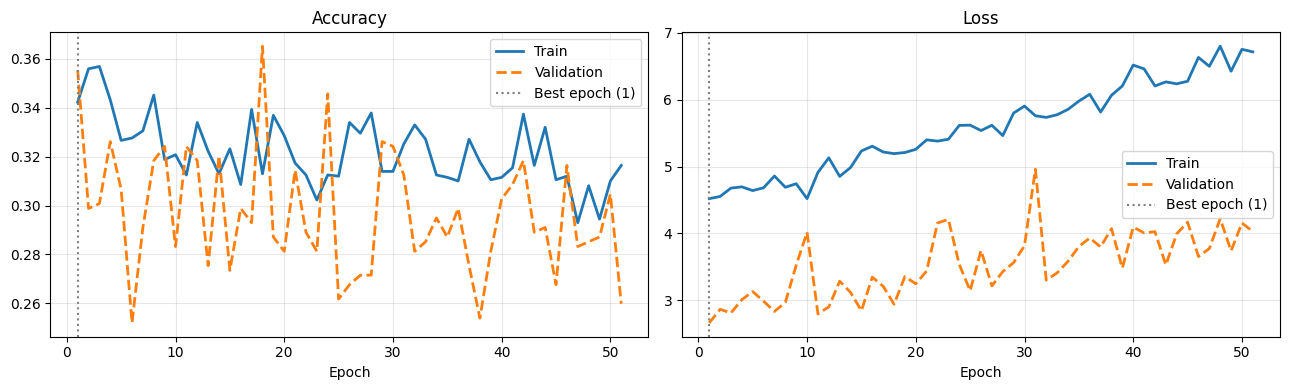

Saved ./performance_plots/training_curves.png


In [36]:
def plot_training_curves(history_dict, out_path):
    epochs  = range(1, len(history_dict["loss"]) + 1)
    best_ep = history_dict["best_epoch"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in [(ax1, "accuracy"), (ax2, "loss")]:
        ax.plot(epochs, history_dict[metric],          label="Train",      linewidth=2)
        ax.plot(epochs, history_dict[f"val_{metric}"], label="Validation", linewidth=2, linestyle="--")
        ax.axvline(best_ep, color="gray", linestyle=":", label=f"Best epoch ({best_ep})")
        ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")

history_dict = dict(history.history)
history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
history_dict["best_epoch"]        = int(np.argmin(history.history["val_loss"])) + 1
history_dict["best_val_accuracy"] = float(min(history.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict, out_path=os.path.join(OUTPUT_DIR, "training_curves.png"))